In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from scipy.stats import (
    binned_statistic_2d
)
from src.plotting import (
    plot_mean_stat,
    discrete_cmap,
    source_line_params
)
from src.samples import(
    load_gpm_dyamond_features,
    load_gpm_dyamond_edge_frac_max_sweep
)
from src.saving import (
    save_figure
)
from src.binned_threshold_delta import (
    BinnedThresholdDelta
)

In [2]:
feature_stats_0p05 = load_gpm_dyamond_features()

# Joint PDFs

## All features

Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/JointPDF_Area_CAF_GPM.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/JointPDF_Area_CAF_colorbar.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/JointPDF_Area_CAF_GEOS.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/JointPDF_Area_CAF_colorbar.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/JointPDF_Area_CAF_gSAM.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/JointPDF_Area_CAF_colorbar.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/JointPDF_Area_CAF_ICON.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/JointPDF_Area_CAF_colorbar.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/JointP

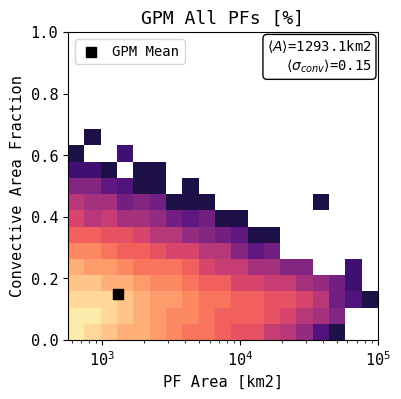

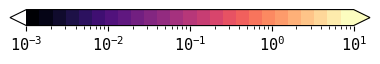

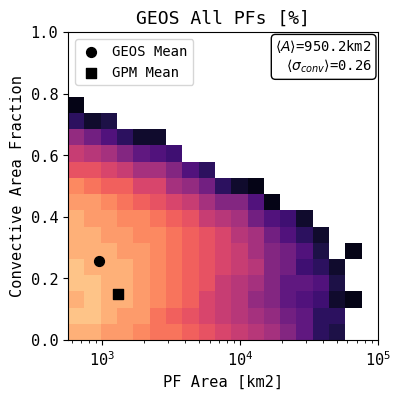

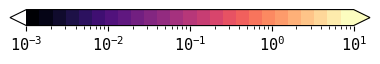

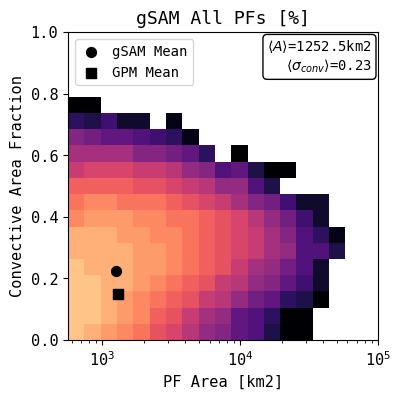

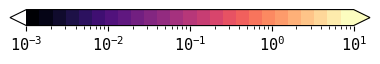

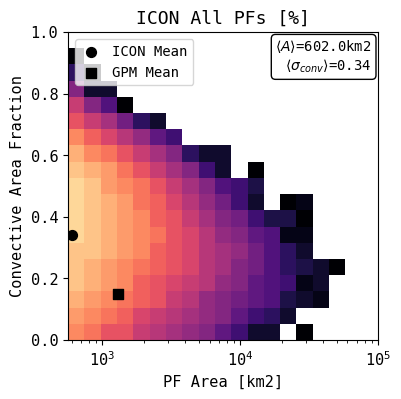

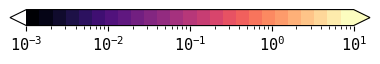

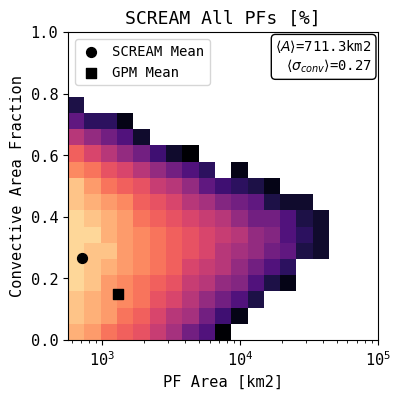

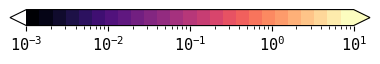

In [23]:
for source, df in feature_stats_0p05.items():

    x_data = df['area_km2']
    y_data = df['px_ge_10mmhr'] / df['size_px']
    x_bins = np.logspace(2.75, 5, 20)
    y_bins = np.linspace(0, 1, 20)
    cmap = discrete_cmap(plt.cm.magma, 25)
    norm = colors.LogNorm(vmin=1e-3, vmax=1e1)
    cmap.set_under('white')
    cmap.set_bad('white')
    mean_color = 'black'
    obs_marker = 's'
    model_marker = 'o'
    fig, ax, cbar_fig, cbar_ax, data = plot_mean_stat(
        x_data=x_data,
        y_data=y_data,
        x_bins=x_bins,
        y_bins=y_bins,
        data_to_bin=None,
        statistic='count',
        density=True,
        cmap=cmap,
        norm=norm,
        figsize=(4,4),
        return_data=True,
        return_colorbar_separate=True
    )

    # Add marker showing the average value
    def _plot_mean(ax, x_data, y_data, color, marker, label, legend=False, add_text=False):
        mean_x, mean_y = np.nanmean(x_data), np.nanmean(y_data)
        ax.scatter(mean_x, mean_y, label=label, color=color, marker=marker, s=50)
        if add_text:
            text = fr"$\langle A\rangle$={mean_x:.1f}km2" + "\n" + rf"$\langle\sigma_{{conv}}\rangle$={mean_y:.2f}"
            ax.text(
                0.98, 0.98, text,
                transform=ax.transAxes,
                ha="right",
                va="top",
                fontsize=10,
                bbox=dict(
                    boxstyle="round,pad=0.3",
                    facecolor="white",
                    alpha=0.99,
                    edgecolor="black",
                ),
            )
        if legend:
            ax.legend(loc='upper left', fontsize=10)

    if source=="GPM":
        # Observations: own mean only, it IS the reference
        _plot_mean(ax, x_data, y_data, color=mean_color, marker=obs_marker, label='GPM Mean', add_text=True, legend=True)
        # Stash the observed distribution so the model panels can overplot it
        x_obs, y_obs = x_data, y_data
    else:
        # Model: own mean, then the GPM mean for the obs-vs-model comparison
        _plot_mean(ax, x_data, y_data, color=mean_color, marker=model_marker, label=f'{source} Mean', add_text=True)
        _plot_mean(ax, x_obs, y_obs, color=mean_color, marker=obs_marker, label='GPM Mean', add_text=False, legend=True)

    ax.set_xscale('log')
    ax.set_xlabel('PF Area [km2]')
    ax.set_ylabel('Convective Area Fraction')
    ax.set_title(f'{source} All PFs [%]')

    save_figure(fig, f'JointPDF_Area_CAF_{source}.pdf')
    save_figure(cbar_fig, f'JointPDF_Area_CAF_colorbar.pdf')

## Extreme Features

Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/JointPDF_ExPFs_Area_CAF_GPM.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/JointPDF_ExPFs_Area_CAF_colorbar.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/JointPDF_ExPFs_Area_CAF_GEOS.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/JointPDF_ExPFs_Area_CAF_colorbar.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/JointPDF_ExPFs_Area_CAF_gSAM.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/JointPDF_ExPFs_Area_CAF_colorbar.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/JointPDF_ExPFs_Area_CAF_ICON.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/JointPDF_ExPFs_Area_CAF_colorbar.pdf as PDF ...
Saving /Users/pedro/Projects/Codi

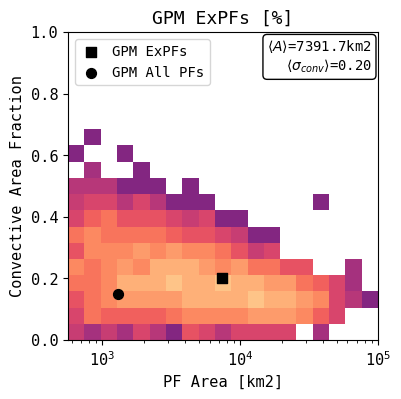

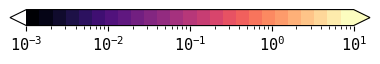

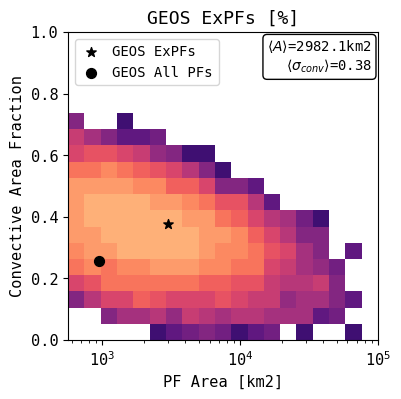

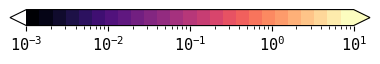

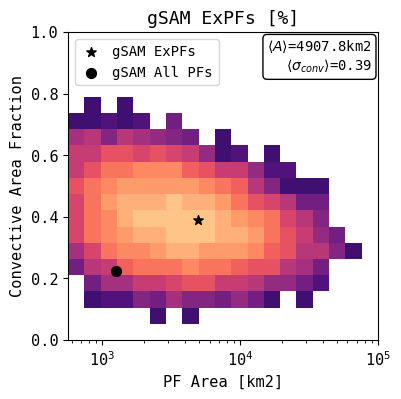

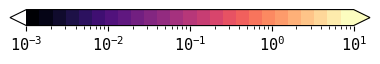

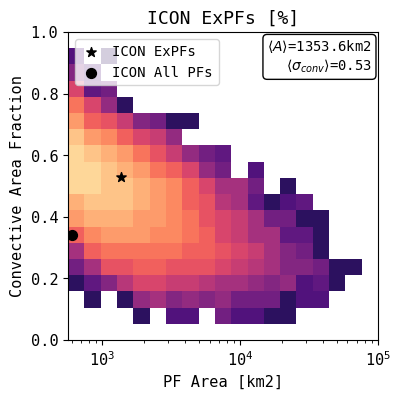

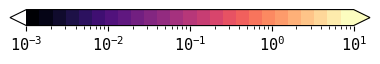

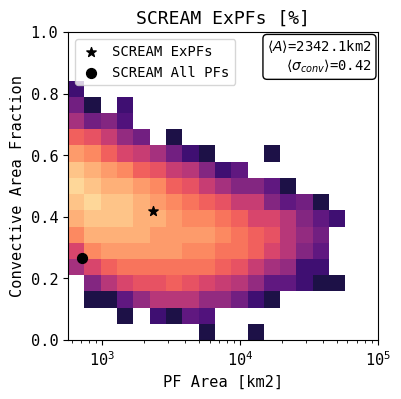

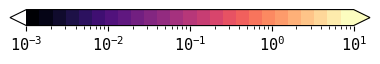

In [24]:
for source, df in feature_stats_0p05.items():

    # Keep the All PFs (unfiltered) distribution before thresholding, for the
    # extremes-vs-non-extremes comparison within this same source
    x_data_allpfs = df['area_km2']
    y_data_allpfs = df['px_ge_10mmhr'] / df['size_px']

    thresh = df['max_precip_mm_hr'].quantile(0.95)
    df = df.filter(
        pl.col("max_precip_mm_hr") >= thresh
    )

    x_data = df['area_km2']
    y_data = df['px_ge_10mmhr'] / df['size_px']
    x_bins = np.logspace(2.75, 5, 20)
    y_bins = np.linspace(0, 1, 20)
    cmap = discrete_cmap(plt.cm.magma, 25)
    norm = colors.LogNorm(vmin=1e-3, vmax=1e1)
    cmap.set_under('white')
    cmap.set_bad('white')
    mean_color = 'black'
    obs_marker = 's'
    model_marker = '*'
    allpfs_marker = 'o'  # marker for this source's own All PFs mean
    fig, ax, cbar_fig, cbar_ax, data = plot_mean_stat(
        x_data=x_data,
        y_data=y_data,
        x_bins=x_bins,
        y_bins=y_bins,
        data_to_bin=None,
        statistic='count',
        density=True,
        cmap=cmap,
        norm=norm,
        figsize=(4,4),
        return_data=True,
        return_colorbar_separate=True
    )

    # Add marker showing the average value
    def _plot_mean(ax, x_data, y_data, color, marker, label, legend=False, add_text=False):
        mean_x, mean_y = np.nanmean(x_data), np.nanmean(y_data)
        ax.scatter(mean_x, mean_y, label=label, color=color, marker=marker, s=50)
        if add_text:
            text = fr"$\langle A\rangle$={mean_x:.1f}km2" + "\n" + rf"$\langle\sigma_{{conv}}\rangle$={mean_y:.2f}"
            ax.text(
                0.98, 0.98, text,
                transform=ax.transAxes,
                ha="right",
                va="top",
                fontsize=10,
                bbox=dict(
                    boxstyle="round,pad=0.3",
                    facecolor="white",
                    alpha=0.99,
                    edgecolor="black",
                ),
            )
        if legend:
            ax.legend(loc='upper left', fontsize=10)

    if source=="GPM":
        # Observed extremes: own mean, it IS the reference
        _plot_mean(ax, x_data, y_data, color=mean_color, marker=obs_marker, label='GPM ExPFs', add_text=True)
        # Stash the observed extremes so the model panels can overplot them
        x_obs, y_obs = x_data, y_data
        # Same source, no threshold: extremes vs non extremes
        _plot_mean(ax, x_data_allpfs, y_data_allpfs, color=mean_color, marker=allpfs_marker, label='GPM All PFs', add_text=False, legend=True)
    else:
        # Model extremes: own mean
        _plot_mean(ax, x_data, y_data, color=mean_color, marker=model_marker, label=f'{source} ExPFs', add_text=True)  
        # Same source, no threshold: extremes vs non extremes
        _plot_mean(ax, x_data_allpfs, y_data_allpfs, color=mean_color, marker=allpfs_marker, label=f'{source} All PFs', add_text=False, legend=True)
        # GPM extremes: model vs observations
        # _plot_mean(ax, x_obs, y_obs, color=mean_color, marker=obs_marker, label='GPM ExPFs', add_text=False)

    ax.set_xscale('log')
    ax.set_xlabel('PF Area [km2]')
    ax.set_ylabel('Convective Area Fraction')
    ax.set_title(f'{source} ExPFs [%]')

    save_figure(fig, f'JointPDF_ExPFs_Area_CAF_{source}.pdf')
    save_figure(cbar_fig, f'JointPDF_ExPFs_Area_CAF_colorbar.pdf')

## Average $P_{max}$

Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/JointPDF_ExPFs_Area_CAF_GPM.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/JointPDF_ExPFs_Area_CAF_colorbar.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/JointPDF_ExPFs_Area_CAF_GEOS.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/JointPDF_ExPFs_Area_CAF_colorbar.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/JointPDF_ExPFs_Area_CAF_gSAM.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/JointPDF_ExPFs_Area_CAF_colorbar.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/JointPDF_ExPFs_Area_CAF_ICON.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/JointPDF_ExPFs_Area_CAF_colorbar.pdf as PDF ...
Saving /Users/pedro/Projects/Codi

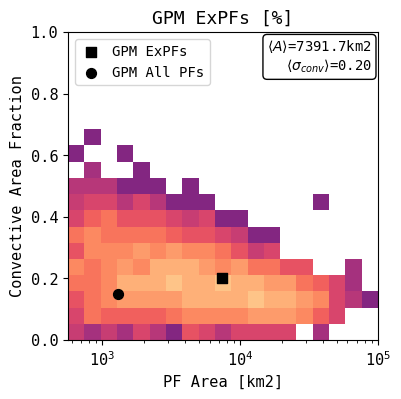

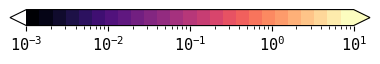

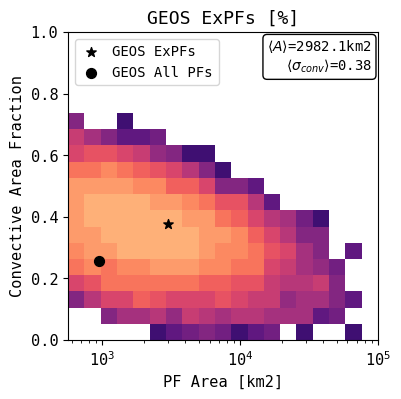

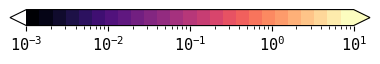

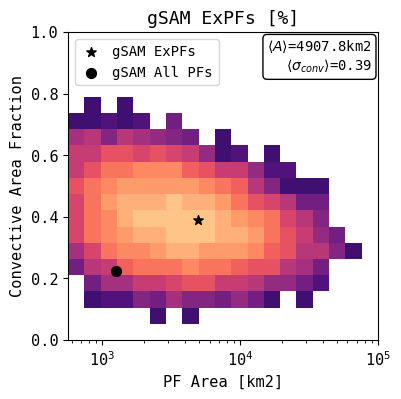

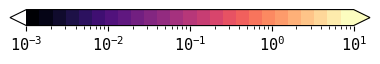

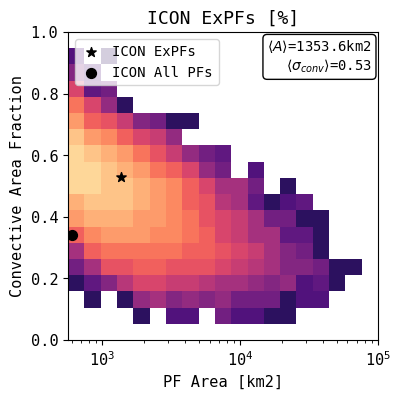

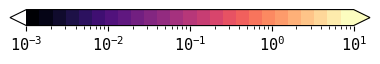

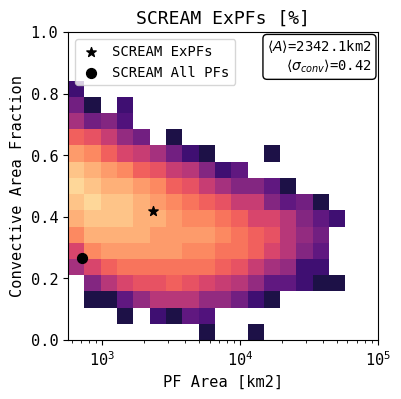

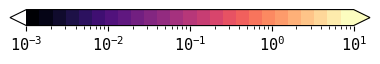

In [25]:
for source, df in feature_stats_0p05.items():

    # Keep the All PFs (unfiltered) distribution before thresholding, for the
    # extremes-vs-non-extremes comparison within this same source
    x_data_allpfs = df['area_km2']
    y_data_allpfs = df['px_ge_10mmhr'] / df['size_px']

    thresh = df['max_precip_mm_hr'].quantile(0.95)
    df = df.filter(
        pl.col("max_precip_mm_hr") >= thresh
    )

    x_data = df['area_km2']
    y_data = df['px_ge_10mmhr'] / df['size_px']
    x_bins = np.logspace(2.75, 5, 20)
    y_bins = np.linspace(0, 1, 20)
    cmap = discrete_cmap(plt.cm.magma, 25)
    norm = colors.LogNorm(vmin=1e-3, vmax=1e1)
    cmap.set_under('white')
    cmap.set_bad('white')
    mean_color = 'black'
    obs_marker = 's'
    model_marker = '*'
    allpfs_marker = 'o'  # marker for this source's own All PFs mean
    fig, ax, cbar_fig, cbar_ax, data = plot_mean_stat(
        x_data=x_data,
        y_data=y_data,
        x_bins=x_bins,
        y_bins=y_bins,
        data_to_bin=None,
        statistic='count',
        density=True,
        cmap=cmap,
        norm=norm,
        figsize=(4,4),
        return_data=True,
        return_colorbar_separate=True
    )

    # Add marker showing the average value
    def _plot_mean(ax, x_data, y_data, color, marker, label, legend=False, add_text=False):
        mean_x, mean_y = np.nanmean(x_data), np.nanmean(y_data)
        ax.scatter(mean_x, mean_y, label=label, color=color, marker=marker, s=50)
        if add_text:
            text = fr"$\langle A\rangle$={mean_x:.1f}km2" + "\n" + rf"$\langle\sigma_{{conv}}\rangle$={mean_y:.2f}"
            ax.text(
                0.98, 0.98, text,
                transform=ax.transAxes,
                ha="right",
                va="top",
                fontsize=10,
                bbox=dict(
                    boxstyle="round,pad=0.3",
                    facecolor="white",
                    alpha=0.99,
                    edgecolor="black",
                ),
            )
        if legend:
            ax.legend(loc='upper left', fontsize=10)

    if source=="GPM":
        # Observed extremes: own mean, it IS the reference
        _plot_mean(ax, x_data, y_data, color=mean_color, marker=obs_marker, label='GPM ExPFs', add_text=True)
        # Stash the observed extremes so the model panels can overplot them
        x_obs, y_obs = x_data, y_data
        # Same source, no threshold: extremes vs non extremes
        _plot_mean(ax, x_data_allpfs, y_data_allpfs, color=mean_color, marker=allpfs_marker, label='GPM All PFs', add_text=False, legend=True)
    else:
        # Model extremes: own mean
        _plot_mean(ax, x_data, y_data, color=mean_color, marker=model_marker, label=f'{source} ExPFs', add_text=True)  
        # Same source, no threshold: extremes vs non extremes
        _plot_mean(ax, x_data_allpfs, y_data_allpfs, color=mean_color, marker=allpfs_marker, label=f'{source} All PFs', add_text=False, legend=True)
        # GPM extremes: model vs observations
        # _plot_mean(ax, x_obs, y_obs, color=mean_color, marker=obs_marker, label='GPM ExPFs', add_text=False)

    ax.set_xscale('log')
    ax.set_xlabel('PF Area [km2]')
    ax.set_ylabel('Convective Area Fraction')
    ax.set_title(f'{source} ExPFs [%]')

    save_figure(fig, f'JointPDF_ExPFs_Area_CAF_{source}.pdf')
    save_figure(cbar_fig, f'JointPDF_ExPFs_Area_CAF_colorbar.pdf')

# Average Pmax

Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/Mean_Pmax_A_CAF_GPM.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/Mean_Pmax_A_CAF_colorbar.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/Mean_Pmax_A_CAF_GEOS.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/Mean_Pmax_A_CAF_colorbar.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/Mean_Pmax_A_CAF_gSAM.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/Mean_Pmax_A_CAF_colorbar.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/Mean_Pmax_A_CAF_ICON.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/Mean_Pmax_A_CAF_colorbar.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/Mean_Pmax_A_CAF_SCREAM

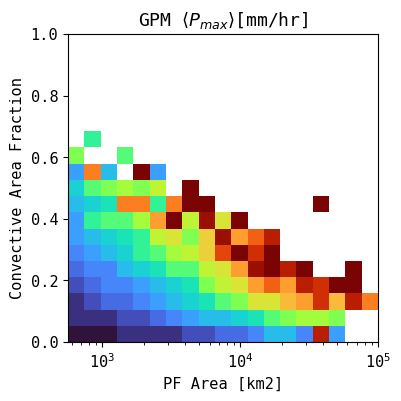

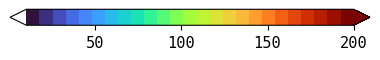

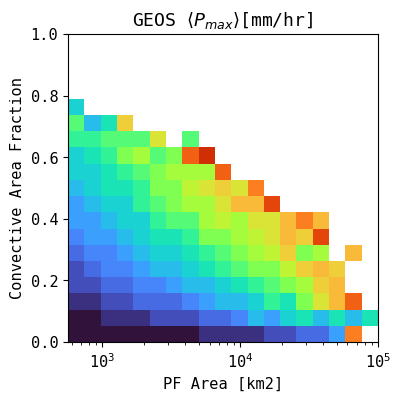

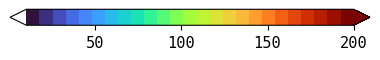

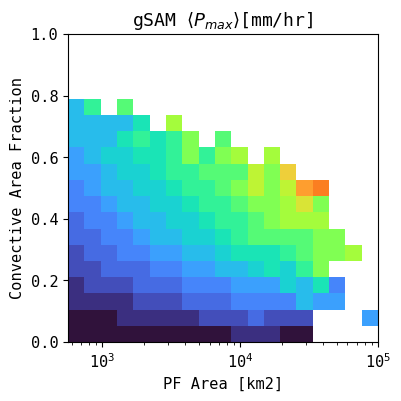

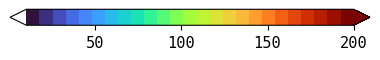

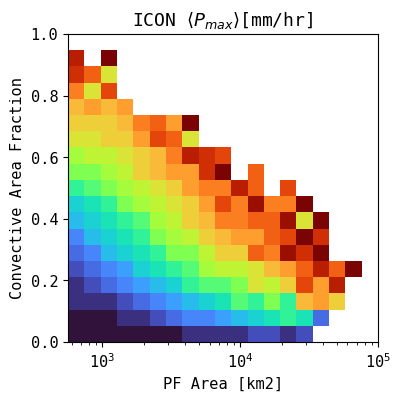

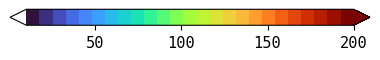

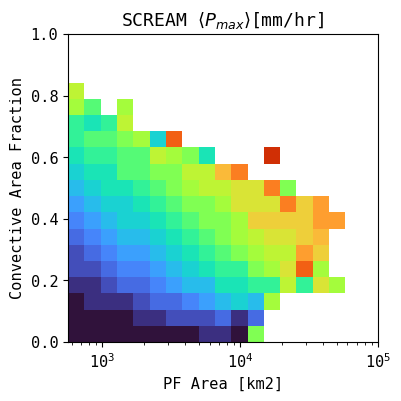

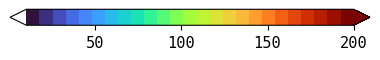

In [3]:
for source, df in feature_stats_0p05.items():
    x_data = df['area_km2']
    y_data = df['px_ge_10mmhr'] / df['size_px']
    x_bins = np.logspace(2.75, 5, 20)
    y_bins = np.linspace(0, 1, 20)
    cmap = discrete_cmap(plt.cm.turbo, 25)
    norm = colors.Normalize(vmin=10, vmax=200)
    cmap.set_under('white')
    cmap.set_bad('white')
    mean_color = 'black'
    obs_marker = 's'
    model_marker = '*'
    fig, ax, cbar_fig, cbar_ax, data = plot_mean_stat(
        x_data=x_data,
        y_data=y_data,
        x_bins=x_bins,
        y_bins=y_bins,
        data_to_bin=df['max_precip_mm_hr'] ,
        statistic=np.nanmean,
        density=False,
        cmap=cmap,
        norm=norm,
        figsize=(4,4),
        return_data=True,
        return_colorbar_separate=True
    )

    ax.set_xscale('log')
    ax.set_xlabel('PF Area [km2]')
    ax.set_ylabel('Convective Area Fraction')
    ax.set_title(f'{source} ' + '$\\langle P_{max}\\rangle$[mm/hr]')
    save_figure(fig, f'Mean_Pmax_A_CAF_{source}.pdf')
    save_figure(cbar_fig, f'Mean_Pmax_A_CAF_colorbar.pdf')

# Computing $\Delta P_{max}$

/Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/src/binned_threshold_delta.py:29: UserWarning: linewidths is ignored by contourf
  "filled_bins": int(filled.sum()),


GPM $\Delta P_{\max}$ [%] count-weighted significant-bin mean: 27.454% (unweighted: 34.301%, 27/43 bins significant)
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/DeltaPmax_GPM.pdf as PDF ...


/Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/src/binned_threshold_delta.py:29: UserWarning: linewidths is ignored by contourf
  "filled_bins": int(filled.sum()),


GEOS $\Delta P_{\max}$ [%] count-weighted significant-bin mean: 17.963% (unweighted: 18.978%, 34/99 bins significant)
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/DeltaPmax_GEOS.pdf as PDF ...


/Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/src/binned_threshold_delta.py:29: UserWarning: linewidths is ignored by contourf
  "filled_bins": int(filled.sum()),


gSAM $\Delta P_{\max}$ [%] count-weighted significant-bin mean: 15.948% (unweighted: 15.789%, 62/92 bins significant)
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/DeltaPmax_gSAM.pdf as PDF ...


/Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/src/binned_threshold_delta.py:29: UserWarning: linewidths is ignored by contourf
  "filled_bins": int(filled.sum()),


ICON $\Delta P_{\max}$ [%] count-weighted significant-bin mean: 29.187% (unweighted: 31.782%, 54/93 bins significant)
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/DeltaPmax_ICON.pdf as PDF ...


/Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/src/binned_threshold_delta.py:29: UserWarning: linewidths is ignored by contourf
  "filled_bins": int(filled.sum()),


SCREAM $\Delta P_{\max}$ [%] count-weighted significant-bin mean: 32.797% (unweighted: 28.775%, 61/89 bins significant)
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/DeltaPmax_SCREAM.pdf as PDF ...


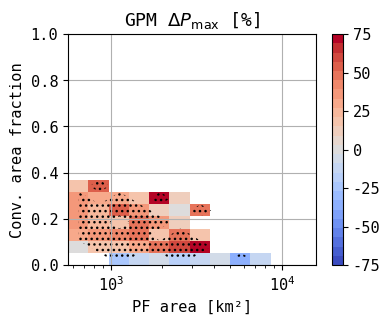

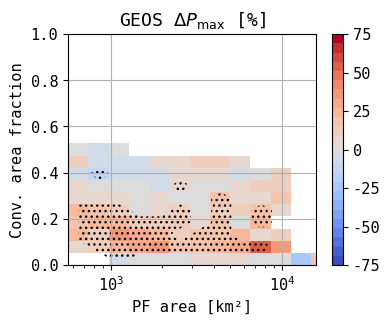

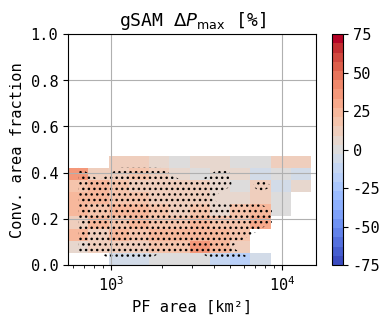

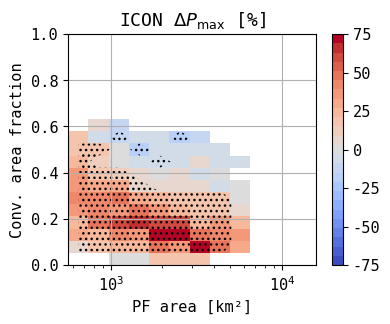

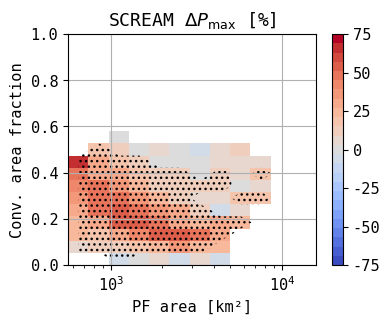

In [44]:
_RHO_LOW = 0.5
_RHO_HIGH = 0.9
_GROUP_MIN = 10
_N_PERM = 200

x_bins = np.logspace(2.75, 5, 20)
y_bins = np.linspace(0, 1, 20)

grids = {}
for source, df in feature_stats_0p05.items():
    btd = BinnedThresholdDelta(
        data_to_sort=df["largest_core_10mmhr_px"] / df["px_ge_10mmhr"],
        data_to_diff=df["max_precip_mm_hr"],
        x_data=df["area_km2"],
        y_data=df["px_ge_10mmhr"] / df["size_px"],
        x_bins=x_bins,
        y_bins=y_bins,
        low_threshold=_RHO_LOW,
        high_threshold=_RHO_HIGH,
        percent_diff=True,
        group_min=_GROUP_MIN,
        n_perm=_N_PERM,
    )

    fig, ax, s, wtd_sig_mean, p, counts = btd.plot(
        xlabel="PF area [km²]",
        ylabel="Conv. area fraction",
        title=(
            rf"{source} $\Delta P_{{\max}}$ [%]"
        ),  
        cmap=discrete_cmap(plt.cm.coolwarm, 25),
        norm=colors.TwoSlopeNorm(vmin=-75, vcenter=0, vmax=75),
        return_p=True,
        return_counts=True,
    )
    ax.set_xlim(None, 10**(4.2))
    grids[source] = dict(s=s, p=p, counts=counts, group_counts=btd.group_counts,
                         n_dropped=btd.n_dropped, headline=wtd_sig_mean)

    save_figure(fig, f'DeltaPmax_{source}.pdf')

In [ ]:
_N_BOOT = 2000
_ALPHA = 0.05


def _prep_bootstrap(df, x_bins, y_bins, rho_low=_RHO_LOW, rho_high=_RHO_HIGH):
    """Per-row bin index and low/high group label. Computed once."""

    rho = (df["largest_core_10mmhr_px"] / df["px_ge_10mmhr"]).to_numpy()
    v = df["max_precip_mm_hr"].to_numpy().astype(float)
    x = df["area_km2"].to_numpy()
    y = (df["px_ge_10mmhr"] / df["size_px"]).to_numpy()

    ix = np.digitize(x, x_bins) - 1
    iy = np.digitize(y, y_bins) - 1

    nx, ny = len(x_bins) - 1, len(y_bins) - 1
    inside = (ix >= 0) & (ix < nx) & (iy >= 0) & (iy < ny) & np.isfinite(v)

    grp = np.full(len(v), -1, dtype=np.int8)
    grp[rho <= rho_low] = 0
    grp[rho >= rho_high] = 1

    keep = inside & (grp >= 0)
    return dict(flat=(iy[keep] * nx + ix[keep]).astype(np.int64),
                grp=grp[keep], v=v[keep], nbins=nx * ny)


def _delta_from_index(idx, prep, group_min=_GROUP_MIN):
    """Per-bin percent difference for one (re)sample of rows."""

    flat, grp, v, nbins = prep["flat"][idx], prep["grp"][idx], prep["v"][idx], prep["nbins"]

    means, counts = [], []
    for g in (0, 1):
        m = grp == g
        n = np.bincount(flat[m], minlength=nbins)
        s = np.bincount(flat[m], weights=v[m], minlength=nbins)
        with np.errstate(invalid="ignore", divide="ignore"):
            means.append(np.where(n > 0, s / np.maximum(n, 1), np.nan))
        counts.append(n)

    lo_mean, hi_mean = means
    ok = (counts[0] >= group_min) & (counts[1] >= group_min) & (lo_mean > 0)

    s = np.full(nbins, np.nan)
    s[ok] = 100.0 * (hi_mean[ok] - lo_mean[ok]) / lo_mean[ok]
    return s, counts[0] + counts[1], ok


def _bootstrap_headline(df, x_bins, y_bins, n_boot=_N_BOOT, alpha=_ALPHA, seed=0):
    """iid bootstrap CI on the count-weighted mean Delta."""

    prep = _prep_bootstrap(df, x_bins, y_bins)
    n = len(prep["v"])
    rng = np.random.default_rng(seed)

    # bin set and weights fixed from the full sample, so only the per-bin
    # Delta varies between draws
    s_full, w_full, ok_full = _delta_from_index(np.arange(n), prep)
    w = np.where(ok_full, w_full, 0.0).astype(float)
    point = float(np.sum(s_full[ok_full] * w[ok_full]) / np.sum(w[ok_full]))

    out = np.full(n_boot, np.nan)
    for b in range(n_boot):
        idx = rng.integers(0, n, n)
        s_b, _, ok_b = _delta_from_index(idx, prep)

        use = ok_full & ok_b
        if use.any():
            out[b] = np.sum(s_b[use] * w[use]) / np.sum(w[use])

    lo, hi = np.nanpercentile(out, [100 * alpha / 2, 100 * (1 - alpha / 2)])
    return point, lo, hi, out


# --- collect ---
boot = {}
for source, df in feature_stats_0p05.items():
    point, lo, hi, draws = _bootstrap_headline(df, x_bins, y_bins)
    boot[source] = dict(point=point, lo=lo, hi=hi, draws=draws)
    print(f"{source:>7}: {point:+6.2f}%  [{lo:+6.2f}, {hi:+6.2f}]  (n={df.height:,})")

    GPM: +19.63%  [+16.81, +23.12]  (n=62,059)
   GEOS:  +9.72%  [ +8.79, +11.14]  (n=321,979)
   gSAM: +14.58%  [+13.81, +15.60]  (n=309,108)
   ICON: +23.26%  [+21.56, +26.13]  (n=628,422)
 SCREAM: +31.04%  [+29.81, +32.70]  (n=636,968)


Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/DeltaPmax_bar.pdf as PDF ...


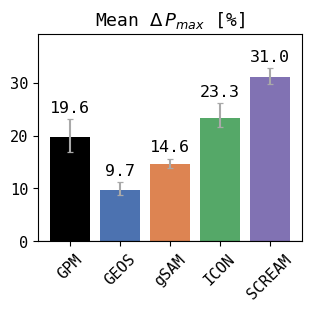

In [39]:
# --- bar plot ---
order = ["GPM"] + [k for k in boot if k != "GPM"]

vals = np.array([boot[k]["point"] for k in order])
lo   = np.array([boot[k]["lo"] for k in order])
hi   = np.array([boot[k]["hi"] for k in order])

# percentile CIs are asymmetric, so yerr takes the (2, N) distance-from-point form
yerr = np.clip(np.vstack([vals - lo, hi - vals]), 0, None)

fig, ax = plt.subplots(figsize=(3, 3), constrained_layout=True)

bars = ax.bar(
    order, vals,
    color=[source_line_params(k)["color"] for k in order],
    yerr=yerr, capsize=2.5,
    error_kw=dict(ecolor="darkgrey", elinewidth=1.5, capthick=0.9, zorder=3),
)

ax.axhline(0, color="k", lw=0.8)

# label above the whisker rather than the bar top
for bar, v, h in zip(bars, vals, hi):
    ax.annotate(f"{v:.1f}", (bar.get_x() + bar.get_width() / 2, h),
                xytext=(0, 3), textcoords="offset points",
                ha="center", va="bottom", fontsize=12)

ax.set_title(rf"Mean $\Delta\,P_{{max}}$ [%]")
ax.tick_params(axis="x", rotation=45)
ax.margins(y=0.20)

save_figure(fig, 'DeltaPmax_bar.pdf')

# Sensitivity sweep

In [5]:
_ALPHA = 0.05
_N_BOOT_SWEEP = 200          # raise for the final version
_GROUP_MIN = 10
_N_PERM = 200

x_bins = np.logspace(2.75, 5, 20)
y_bins = np.linspace(0, 1, 20)

RHO_PAIRS = [(0.5, 0.65), (0.5, 0.8), (0.35, 0.65),
             (0.35, 0.8), (0.65, 0.8), (0.65, 0.9)]

feature_stats_sweep = load_gpm_dyamond_edge_frac_max_sweep()


def _prep(df, x_bins, y_bins, low_threshold, high_threshold):
    """Per-row bin index and group label. Flattened as iy*nx + ix."""
    rho = (df["largest_core_10mmhr_px"] / df["px_ge_10mmhr"]).to_numpy()
    v = df["max_precip_mm_hr"].to_numpy().astype(float)
    x = df["area_km2"].to_numpy()
    y = (df["px_ge_10mmhr"] / df["size_px"]).to_numpy()

    nx, ny = len(x_bins) - 1, len(y_bins) - 1
    ix = np.digitize(x, x_bins) - 1
    iy = np.digitize(y, y_bins) - 1

    inside = (ix >= 0) & (ix < nx) & (iy >= 0) & (iy < ny) & np.isfinite(v)
    grp = np.full(len(v), -1, dtype=np.int8)
    grp[rho <= low_threshold] = 0
    grp[rho >= high_threshold] = 1

    keep = inside & (grp >= 0)
    return dict(flat=(iy[keep] * nx + ix[keep]).astype(np.int64),
                grp=grp[keep], v=v[keep], nbins=nx * ny)


def _delta(idx, prep, group_min=_GROUP_MIN):
    """Per-bin percent difference for one (re)sample of rows."""
    flat, grp, v = prep["flat"][idx], prep["grp"][idx], prep["v"][idx]
    nbins = prep["nbins"]

    means, counts = [], []
    for g in (0, 1):
        m = grp == g
        n = np.bincount(flat[m], minlength=nbins)
        tot = np.bincount(flat[m], weights=v[m], minlength=nbins)
        with np.errstate(invalid="ignore", divide="ignore"):
            means.append(np.where(n > 0, tot / np.maximum(n, 1), np.nan))
        counts.append(n)

    lo_mean, hi_mean = means
    ok = (counts[0] >= group_min) & (counts[1] >= group_min) & (lo_mean > 0)

    s = np.full(nbins, np.nan)
    s[ok] = 100.0 * (hi_mean[ok] - lo_mean[ok]) / lo_mean[ok]
    return s, counts[0] + counts[1], ok


def headline_ci(df, x_bins, y_bins, low_threshold, high_threshold,
                group_min=_GROUP_MIN, n_perm=_N_PERM, n_boot=_N_BOOT_SWEEP,
                alpha=_ALPHA, seed=0, **kw):
    """Point estimate plus bootstrap CI over the bins the permutation test selects.

    The significant-bin set is frozen from the full sample, so the interval
    reflects uncertainty in Delta given those bins, not in which bins are
    selected. Nesting the permutation test inside the bootstrap would be
    n_boot x n_perm times more expensive.
    """
    btd = BinnedThresholdDelta(
        data_to_sort=df["largest_core_10mmhr_px"] / df["px_ge_10mmhr"],
        data_to_diff=df["max_precip_mm_hr"],
        x_data=df["area_km2"],
        y_data=df["px_ge_10mmhr"] / df["size_px"],
        x_bins=x_bins, y_bins=y_bins,
        low_threshold=low_threshold, high_threshold=high_threshold,
        percent_diff=True, group_min=group_min, n_perm=n_perm, **kw,
    )
    s_btd, p_btd, _ = btd.compute()
    summary = btd.summarise(s_btd, p_btd, btd.group_counts)
    point = summary["count_weighted_sig_mean"]

    prep = _prep(df, x_bins, y_bins, low_threshold, high_threshold)
    n = len(prep["v"])

    sig = (np.asarray(p_btd) < alpha) & np.isfinite(np.asarray(s_btd))
    sig = sig.ravel()
    if sig.size != prep["nbins"]:
        raise ValueError(f"bin mismatch: {sig.size} vs {prep['nbins']}")

    _, w_full, ok_full = _delta(np.arange(n), prep, group_min)
    use_full = sig & ok_full
    w = np.where(use_full, w_full, 0.0).astype(float)

    if not use_full.any():
        return point, np.nan, np.nan, summary

    rng = np.random.default_rng(seed)
    out = np.full(n_boot, np.nan)
    for b in range(n_boot):
        idx = rng.integers(0, n, n)
        s_b, _, ok_b = _delta(idx, prep, group_min)
        use = use_full & ok_b
        if use.any():
            out[b] = np.sum(s_b[use] * w[use]) / np.sum(w[use])

    lo, hi = np.nanpercentile(out, [100 * alpha / 2, 100 * (1 - alpha / 2)])
    return point, lo, hi, summary


sweep = {}
for low, high in RHO_PAIRS:
    for efm, d in feature_stats_sweep.items():
        for source, df in d.items():
            h, lo, hi, summary = headline_ci(df, x_bins, y_bins, low, high)
            sweep[(low, high, efm, source)] = (h, lo, hi)
            print(f"rho {low}/{high}  efm={efm:<5} {source:>8}: "
                  f"{h:6.2f}%  [{lo:6.2f}, {hi:6.2f}]  "
                  f"({summary['sig_bins']}/{summary['filled_bins']} bins)")

rho 0.5/0.65  efm=0.05       GPM:  22.78%  [ 20.52,  25.20]  (35/63 bins)
rho 0.5/0.65  efm=0.05      GEOS:  17.11%  [ 15.64,  18.76]  (41/111 bins)
rho 0.5/0.65  efm=0.05      gSAM:  14.49%  [ 13.89,  15.22]  (65/106 bins)
rho 0.5/0.65  efm=0.05      ICON:  29.30%  [ 27.27,  31.83]  (54/106 bins)
rho 0.5/0.65  efm=0.05    SCREAM:  31.04%  [ 29.80,  32.62]  (69/103 bins)
rho 0.5/0.65  efm=0.1        GPM:  20.56%  [ 18.43,  23.05]  (41/75 bins)
rho 0.5/0.65  efm=0.1       GEOS:  17.64%  [ 16.47,  19.06]  (51/125 bins)
rho 0.5/0.65  efm=0.1       gSAM:  14.30%  [ 13.69,  14.95]  (70/114 bins)
rho 0.5/0.65  efm=0.1       ICON:  28.79%  [ 26.71,  31.31]  (58/114 bins)
rho 0.5/0.65  efm=0.1     SCREAM:  30.87%  [ 29.67,  32.19]  (72/109 bins)
rho 0.5/0.65  efm=0.25       GPM:  19.58%  [ 17.69,  22.38]  (42/79 bins)
rho 0.5/0.65  efm=0.25      GEOS:  17.35%  [ 16.17,  18.77]  (56/139 bins)
rho 0.5/0.65  efm=0.25      gSAM:  13.97%  [ 13.42,  14.62]  (78/124 bins)
rho 0.5/0.65  efm=0.25      

Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/sensitivity/sweep_DeltaPmax.pdf as PDF ...


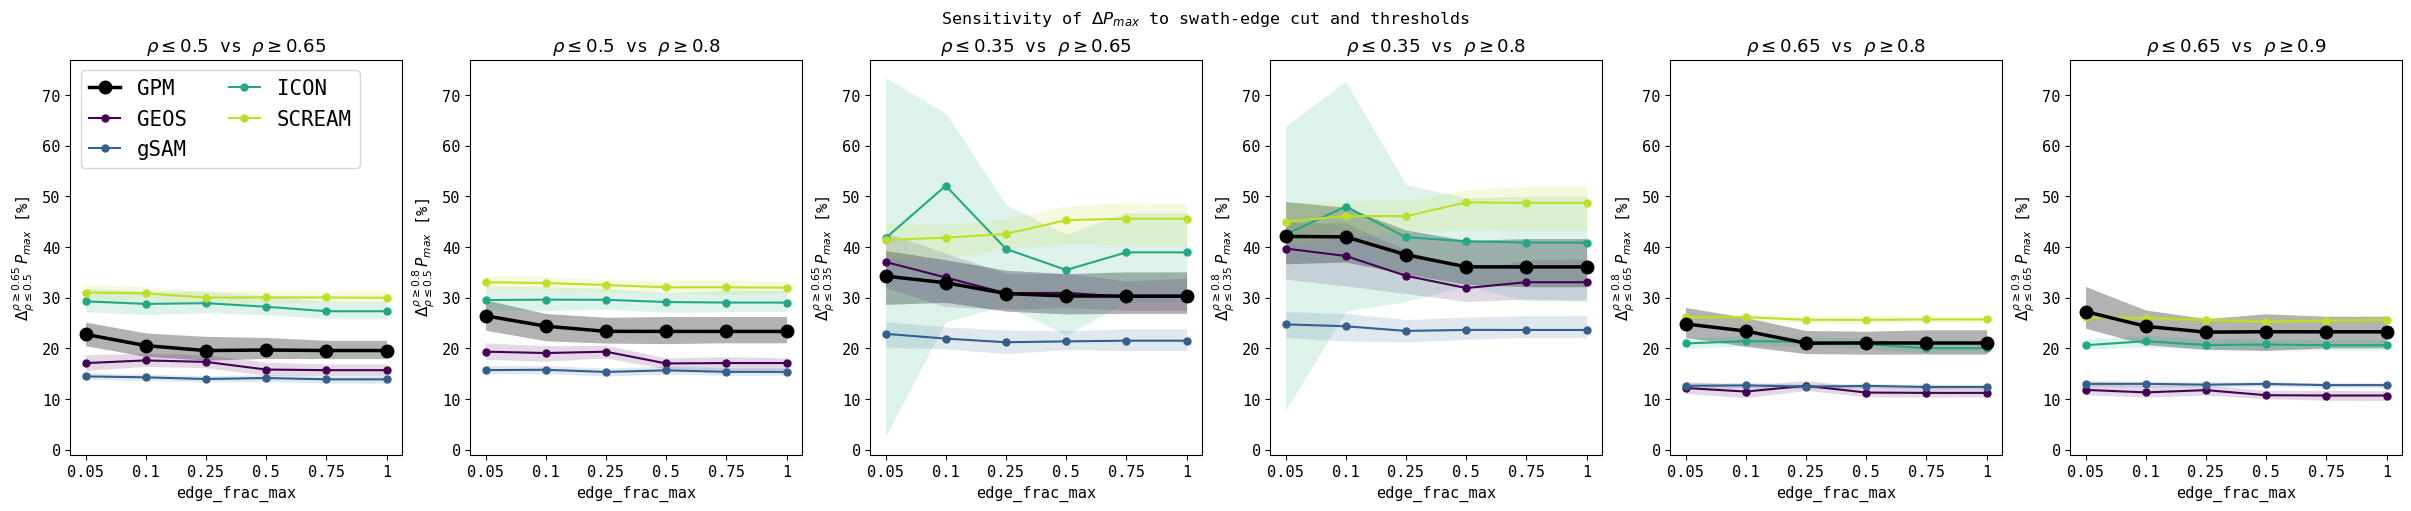

In [6]:
def plot_sweep(low, high, ax, ylim=None):
    xs = sorted(feature_stats_sweep)
    sources = list(feature_stats_sweep[xs[0]])
    pos = np.arange(len(xs))
    model_colors = plt.cm.viridis(np.linspace(0, 0.9, len(sources) - 1))

    for i, source in enumerate(sources):
        vals = np.array([sweep[(low, high, x, source)] for x in xs])
        y, ylo, yhi = vals[:, 0], vals[:, 1], vals[:, 2]

        is_gpm = source == "GPM"
        c = "k" if is_gpm else model_colors[i - 1]

        ax.fill_between(pos, ylo, yhi, color=c,
                        alpha=0.30 if is_gpm else 0.15, lw=0, zorder=1)
        ax.plot(pos, y, "-o", color=c,
                lw=2.5 if is_gpm else 1.5,
                ms=9 if is_gpm else 5,
                zorder=4 if is_gpm else 3,
                label=source)

    ax.set_xticks(pos, [f"{x:g}" for x in xs])
    ax.set_xlabel("edge_frac_max")
    ax.set_ylabel(rf"$\Delta_{{\rho\leq{low}}}^{{\rho\geq{high}}}\,P_{{max}}$ [%]")
    ax.set_title(rf"$\rho \leq {low}$ vs $\rho \geq {high}$")
    if ylim is not None:
        ax.set_ylim(*ylim)


# shared y-range across panels, taken from the bands rather than the points
_all = np.array([v for k, v in sweep.items()])
_lo = np.nanmin(_all[:, 1])
_hi = np.nanmax(_all[:, 2])
_pad = 0.05 * (_hi - _lo)
YLIM = (_lo - _pad, _hi + _pad)

fig, axes = plt.subplots(1, len(RHO_PAIRS), figsize=(24, 5),
                         constrained_layout=True)
for (low, high), ax in zip(RHO_PAIRS, axes.flat):
    plot_sweep(low, high, ax, ylim=YLIM)

axes.flat[0].legend(ncol=2, fontsize=15, loc="upper left", frameon=True)
fig.suptitle(r"Sensitivity of $\Delta P_{max}$ to swath-edge cut and thresholds")
save_figure(fig, 'sensitivity/sweep_DeltaPmax.pdf')